## Report on Students Performance

**Prepared by**: Kristityan Kirilov <br>
**Date**: 11.05.2026 <br>

### Introduction:

The purpose of this report is to examine the factors that affect students educational performance. <br>
Educational performance is important because it reflects students understanding, skills, and academic progress. <br>
This report discusses the main factors influencing performance and suggests ways to improve student achievement. <br>

### Factors Affecting Students Performance:

**Study Habits**: <br>
Good study habits play an important role in academic success. <br>
Students who manage their time well, complete assignments, and revise lessons regularly usually achieve better results. <br>

**Distractions**: <br>
Regular school attendance helps students understand lessons and participate in classroom activities. <br>
Students who miss classes frequently may struggle to keep up with their studies, that includes students also with jobs. <br>
We can use the free time spending to understand how it effects exams scores <br>

**Health and Lifestyle**: <br>
Healthy eating, enough sleep, and regular exercise help students concentrate better in class. <br>
Poor health habits may reduce academic performance. <br>

### Methodology:

We have datasets of two different sources <br>
Our mission is to build multiple predictions models that will show us what effects increase students performance and what decrease it <br>

Data:
1) Training data - used to build the prediction model <br>
2) Testing data - used to evaluate the model performance <br>

Sources:
1) Training Data - https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance
2) Testing Data - https://www.kaggle.com/datasets/aryan208/student-habits-and-academic-performance-dataset

### Setup:

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from utils.print import *

In [52]:
train_data_table = pd.read_csv("../data/train.csv")
test_data_table = pd.read_csv("../data/test.csv")

### Criteria:

In [53]:
SCORE_THRESHOLD = 50
ATTENDANCE_THRESHOLD = 30

def pass_criteria(table):
    pass_score = table['exam_score'] >= SCORE_THRESHOLD
    pass_attendance =table['attendance_percentage'] >= ATTENDANCE_THRESHOLD
    return pass_score & pass_attendance

train_data_table['pass'] = np.where(pass_criteria(train_data_table), 'Pass', 'Failed')
test_data_table['pass'] = np.where(pass_criteria(test_data_table), 'Pass', 'Failed')

### Study Habits:

Good study habits play an important role in academic success. <br>
Students who manage their time well, complete assignments, and revise lessons regularly usually achieve better results. <br>

We want a make **linear dependency** between **study time** and **attendance** to see **how much the attendance improves the students score** <br>
We will use **linear regression model** with features - **study time** and **attendance** and target - **score**, to build score formula <br>
that determines what is the most important feature from the two for students perfomance

#### Data:

In [54]:
model_table = pd.DataFrame({
    "id": train_data_table["student_id"],
    "study_time": train_data_table["study_hours_per_day"],
    "attendance": train_data_table["attendance_percentage"],
    "score": train_data_table["exam_score"]
})

analyze_table = pd.DataFrame({
    "id": test_data_table["student_id"],
    "study_time": round(test_data_table["study_hours_per_day"]),
    "attendance": test_data_table["attendance_percentage"],
    "score": test_data_table["exam_score"]
})

#### Model:

In [55]:
# Define our sets of ids (I), features (X) and target (Y)
I = model_table['id']
X = model_table[['study_time', 'attendance']]
Y = model_table['score']

# Split the data: 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test, I_train, I_test = train_test_split(X, Y, I, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, Y_train)

# Save coefficients in separate variables
study_time_coef = model.coef_[0].round(2)
attendance_coef = model.coef_[1].round(2)
intercept = model.intercept_.round(2)

# Make predictions on the test set
Y_pred = np.clip(model.predict(X_test), None, 100)

# Calculate Mean Squared Error and R-squared score
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

# Create model table
model_data = pd.DataFrame({
    "id": I_test,
    "study_time": X_test["study_time"],
    "attendance": X_test["attendance"],
    "actual_score": Y_test,
    "predicted_score": Y_pred,
    "squared_error": (Y_test - Y_pred) ** 2
})

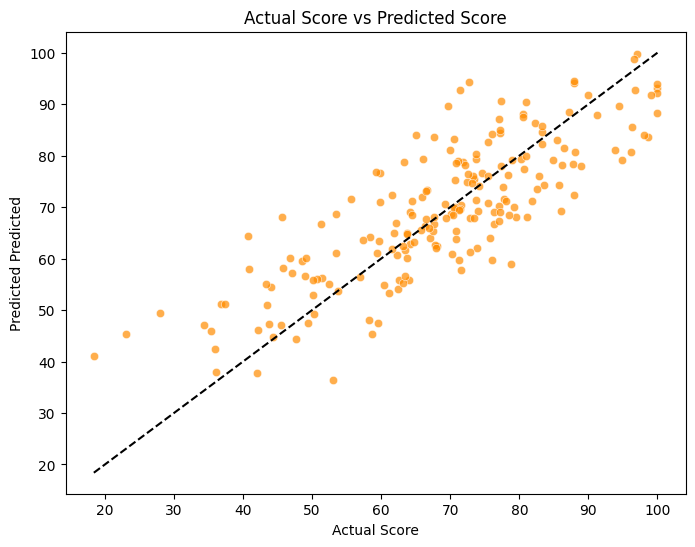

Model Data:
The model explains 66.2% of the variance in the score

Formula:
Score = 9.5 * study_time + 0.15 * attendance + 23.54

Data:
R-squared Score: 0.6623205873459584
Mean Squared Error: 86.59082652468683

Largest Errors:
        id  study_time  attendance  actual_score  predicted_score  \
526  S1526         2.8        95.9          40.7        64.357047   
265  S1265         0.6        79.9          18.4        41.091035   
959  S1959         3.2        95.1          45.7        68.037087   
327  S1327         0.9        89.2          23.1        45.319464   
737  S1737         5.9       100.0          72.7        94.405085   
938  S1938         1.2        97.7          28.0        49.429235   
277  S1277         5.9        89.0          71.4        92.773531   
998  S1998         5.4       100.0          69.7        89.656712   
254  S1254         2.5        78.6          78.8        58.942033   
261  S1261         5.1        81.6          65.1        84.078543   

     squared_

In [56]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=model_data["actual_score"], y=model_data["predicted_score"], color='darkorange', alpha=0.7)

# Add a diagonal line representing perfect predictions
max_val = max(model_data["actual_score"].max(), model_data["predicted_score"].max())
min_val = min(model_data["actual_score"].min(), model_data["predicted_score"].min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.xlabel('Actual Score')
plt.ylabel('Predicted Predicted')
plt.title('Actual Score vs Predicted Score')
plt.show()

print("Model Data:")
print(f"The model explains {r2*100:.1f}% of the variance in the score")
print()
print("Formula:")
print(f"Score = {study_time_coef} * study_time + {attendance_coef} * attendance + {intercept.round(2)}")
print()
print("Data:")
print(f"R-squared Score: {r2}")
print(f"Mean Squared Error: {mse}")
print()
print("Largest Errors:")
print(model_data.sort_values(by="squared_error", ascending=False).head(10))